## Market Basket Analysis: Apriori


In [1]:
!pip install apyori

  Preparing metadata (setup.py) ... done
  Created wheel for apyori: filename=apyori-1.1.2-py3-none-any.whl size=5954 sha256=1f1d59eb8586b45902ca3a23a9f058797576902c677ba2f9e0877c99aefed7ac
  Stored in directory: /root/.cache/pip/wheels/7f/49/e3/42c73b19a264de37129fadaa0c52f26cf50e87de08fb9804af
Successfully built apyori


In [2]:
# Import packages
import pandas as pd
import random
from apyori import apriori
import matplotlib.pyplot as plt

In [3]:
# Step 1: Load the dataset
orders = pd.read_csv('orders.csv')
order_products_prior = pd.read_csv('order_products__prior.csv')
products = pd.read_csv('products.csv')

 - orders.csv: Contains metadata about each order, such as order ID, user ID, and order sequence.
 - order_products__prior.csv: Holds details of previously ordered products, linking order IDs to product IDs.
 - products.csv: Maps product IDs to product names, allowing for meaningful interpretation of transactions.

In [4]:
# Merge datasets to get product names
order_products = order_products_prior.merge(products, on='product_id', how='left')
order_products = order_products.merge(orders, on='order_id', how='left')

# Display dataset sample
display(order_products.head())

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1.0,1.0,Organic Egg Whites,86,16,202279,prior,3,5,9,8.0
1,2,28985,2.0,1.0,Michigan Organic Kale,83,4,202279,prior,3,5,9,8.0
2,2,9327,3.0,0.0,Garlic Powder,104,13,202279,prior,3,5,9,8.0
3,2,45918,4.0,1.0,Coconut Butter,19,13,202279,prior,3,5,9,8.0
4,2,30035,5.0,0.0,Natural Sweetener,17,13,202279,prior,3,5,9,8.0


## Data Preprocessing

In [5]:
# Step 2: Data Preprocessing
# Group products by order_id to create transactions
transactions = order_products.groupby('order_id')['product_name'].apply(list).tolist()

# Create own dataset by randomly selecting transactions
random_sample = random.sample(transactions, 5000)  # Selecting 5000 transactions for analysis

# Display a sample of transactions
for i in range(5):
    print(random_sample[i])

['Vitamin D Organic Milk', 'Natural Chicken Breast Cutlets', 'Organic Strawberries', '100% Apple Juice', 'Original 5-Cheese Pizza', 'Banana']
['I Heart Baby Kale', 'Bread Crumbs', 'Organic Cottage Cheese']
['Black Seedless Grapes']
['Organic Cucumber', 'Healthy Grains Fiber Cinnamon Oat Clusters']
['Sensitive Skin Experts Cleansing Facial Wipes', 'Banana', 'Marketplace Vermont White Cheddar Mac & Cheese', 'Light Mozzarella String Cheese', 'Asparagus Spears', 'Red Apple Bites Multi Pack Healthy Snacks', 'Classic Hummus with Rold Gold Petzels Snack', '100 Calorie  Per Bag Popcorn']


## Step 3: Apply Apriori Algorithm
 - Set minimum support to 0.01, minimum confidence to 0.2, and minimum lift to 1.0

In [6]:
# Step 3: Apply Apriori Algorithm
## Set minimum support to 0.01, minimum confidence to 0.2, and minimum lift to 1.0
rules = apriori(random_sample, min_support=0.01, min_confidence=0.2, min_lift=1.0, min_length=2)
rules = list(rules)
print("Association Rules Generated!")

print('Rules generated: ', len(rules))

print('First rule: ', rules[0])

Association Rules Generated!
Rules generated:  19
First rule:  RelationRecord(items=frozenset({'Organic Baby Spinach', 'Bag of Organic Bananas'}), support=0.0174, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Organic Baby Spinach'}), items_add=frozenset({'Bag of Organic Bananas'}), confidence=0.22193877551020408, lift=1.9675423360833695)])


Change the index value [0] of 'rules[0]' to see a different rule.

## Algorithm Parameters

 - Support: How often a rule appears in transactions.
 - Confidence: The likelihood of a rule being correct.
 - Lift: Strength of a rule (>1 indicates strong association).

## Analysing the Results

Analysing the results may include checking what kind of items are featured in some of the rules. Using the method in the cell below, you can display the rules for the algorithm.

In [7]:
# Step 4: Convert Rules into a Readable Format
formatted_rules = []
for rule in rules:
    for ordered_stat in rule.ordered_statistics:
        formatted_rules.append({
            'Base': tuple(ordered_stat.items_base),
            'Add': tuple(ordered_stat.items_add),
            'Support': rule.support,
            'Confidence': ordered_stat.confidence,
            'Lift': ordered_stat.lift
        })

rules_df = pd.DataFrame(formatted_rules)
display(rules_df)

,Base,Add,Support,Confidence,Lift
0,"(Organic Baby Spinach,)","(Bag of Organic Bananas,)",0.0174,0.221939,1.967542
1,"(Organic Hass Avocado,)","(Bag of Organic Bananas,)",0.0202,0.291066,2.580375
2,"(Organic Raspberries,)","(Bag of Organic Bananas,)",0.0120,0.288462,2.557283
3,"(Organic Strawberries,)","(Bag of Organic Bananas,)",0.0190,0.221445,1.963167
4,"(Organic Whole Milk,)","(Bag of Organic Bananas,)",0.0122,0.268722,2.382291
5,"(Organic Yellow Onion,)","(Bag of Organic Bananas,)",0.0110,0.317919,2.818432
6,"(Cucumber Kirby,)","(Banana,)",0.0116,0.320442,2.110949
7,"(Large Lemon,)","(Banana,)",0.0146,0.269373,1.774524
8,"(Limes,)","(Banana,)",0.0102,0.248780,1.638870
9,"(Organic Avocado,)","(Banana,)",0.0192,0.340426,2.242592


 - Support: How often a rule appears in transactions.
 - Confidence: The likelihood of a rule being correct.
 - Lift: Strength of a rule (>1 indicates strong association).

## Visualisation

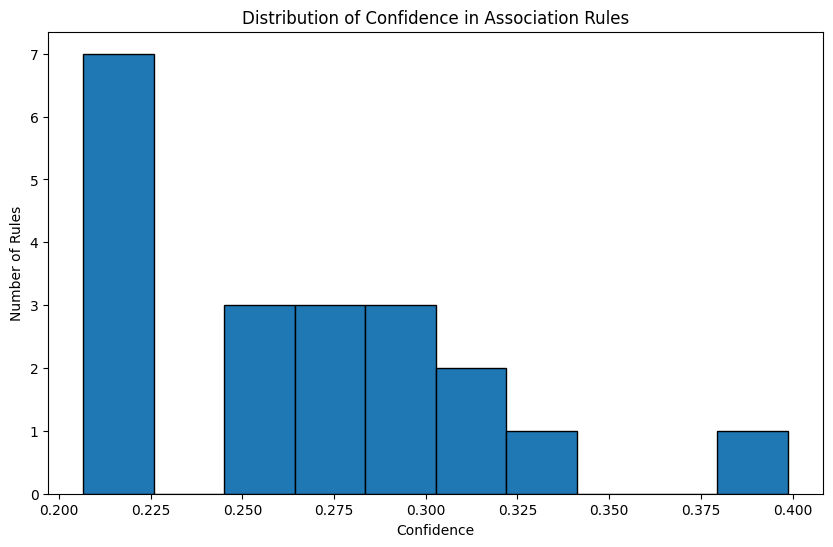

In [8]:
# Step 5: Visualizing Results
plt.figure(figsize=(10, 6))
plt.hist(rules_df['Confidence'], bins=10, edgecolor='black')
plt.xlabel('Confidence')
plt.ylabel('Number of Rules')
plt.title('Distribution of Confidence in Association Rules')
plt.show()

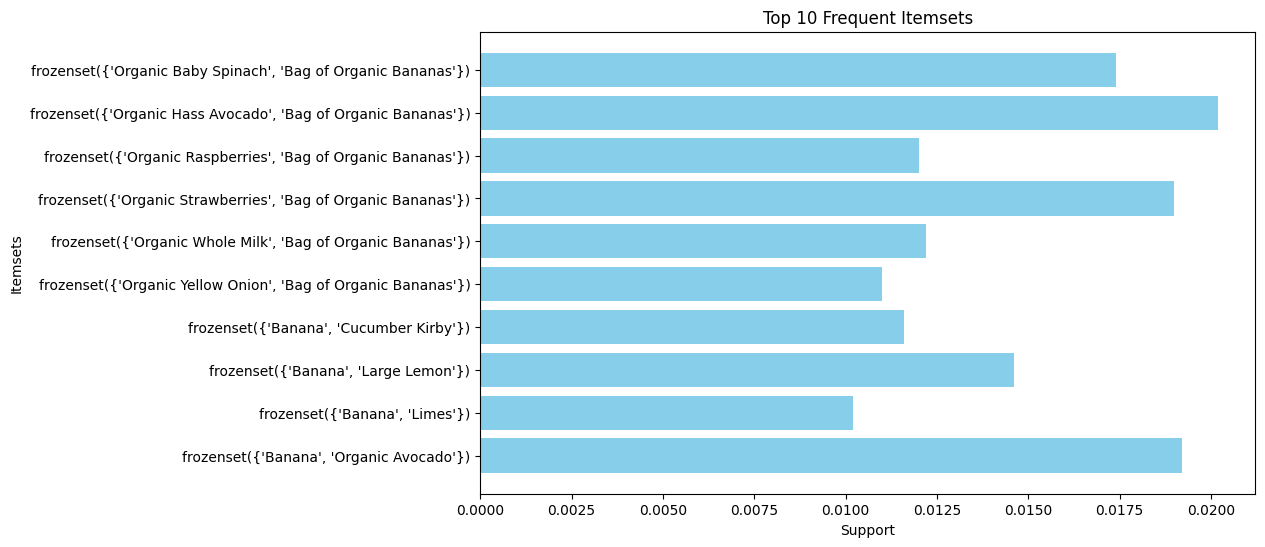

In [9]:
# Additional Visualization: Top Frequent Items
support_values = [rule.support for rule in rules]
items = [str(rule.items) for rule in rules]

plt.figure(figsize=(10, 6))
plt.barh(items[:10], support_values[:10], color='skyblue')
plt.xlabel('Support')
plt.ylabel('Itemsets')
plt.title('Top 10 Frequent Itemsets')
plt.gca().invert_yaxis()
plt.show()

## Tasks:
 - Modify the min_support, min_confidence, and min_lift values and observe the changes.
 - Randomly sample a different subset of transactions and re-run Apriori.
 - Generate different plots to analyse the effects of parameter tuning on rule generation.
 - Add explanation as required.


# Modifying the min_support, min_confidence, and min_lift values and observe the changes.

In [13]:
param_results = []

supports = [0.005, 0.01]
confidences = [0.1, 0.2]
lifts = [0.8, 1]

for s in supports:
    for c in confidences:
        for l in lifts:
            rules_list = list(apriori(transactions, min_support=s, min_confidence=c, min_lift=l))
            param_results.append([s, c, l, len(rules_list)])

param_df = pd.DataFrame(param_results, columns=['Support','Confidence','Lift','Rules'])
param_df

,Support,Confidence,Lift,Rules
0,0.005,0.1,0.8,76
1,0.005,0.1,1.0,75
2,0.005,0.2,0.8,36
3,0.005,0.2,1.0,36
4,0.010,0.1,0.8,16
5,0.010,0.1,1.0,16
6,0.010,0.2,0.8,11
7,0.010,0.2,1.0,11


Lower support means more rules because more item combinations are allowed

Higher confidence gives fewer rules because weak rules are removed

Lift does not change much, so item relationships are not very strong

Changing parameters affects how many rules we get and how strong they are

#Randomly sample a different subset of transactions and re-run Apriori.

In [16]:
# take 50% random transactions
sample_transactions = random.sample(transactions, int(len(transactions)*0.5))

# apply apriori on sampled data
rules_sample = list(apriori(sample_transactions, min_support=0.005, min_confidence=0.1, min_lift=0.8))

print("Rules from full data:", len(rules))
print("Rules from sample data:", len(rules_sample))

Rules from full data: 19
Rules from sample data: 76


Sample data produced more rules due to random variation

Some patterns became more frequent in smaller dataset

Apriori is sensitive to dataset changes

#Generate different plots to analyse the effects of parameter tuning on rule generation

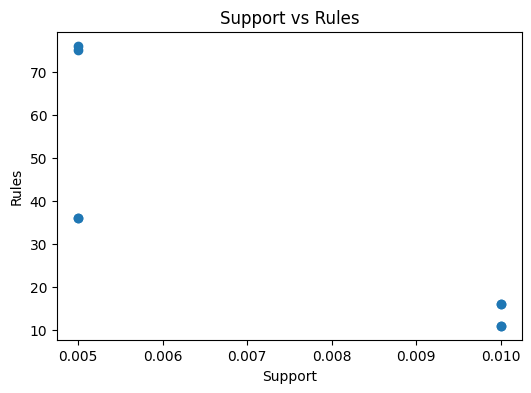

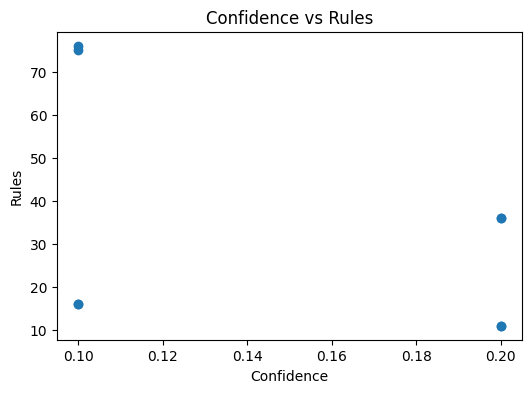

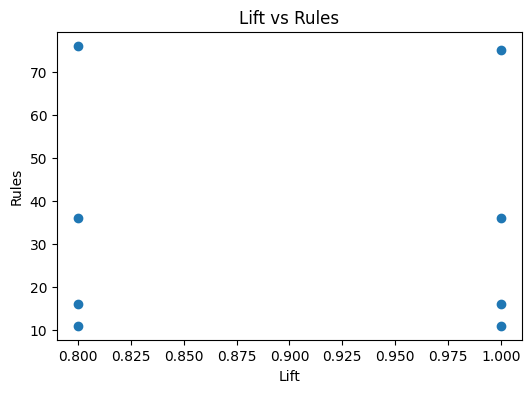

In [19]:
#Support vs Rules
plt.figure(figsize=(6,4))
plt.scatter(param_df['Support'], param_df['Rules'])
plt.xlabel('Support')
plt.ylabel('Rules')
plt.title('Support vs Rules')
plt.show()

#Confidence vs Rules
plt.figure(figsize=(6,4))
plt.scatter(param_df['Confidence'], param_df['Rules'])
plt.xlabel('Confidence')
plt.ylabel('Rules')
plt.title('Confidence vs Rules')
plt.show()

#Lift vs Rules
plt.figure(figsize=(6,4))
plt.scatter(param_df['Lift'], param_df['Rules'])
plt.xlabel('Lift')
plt.ylabel('Rules')
plt.title('Lift vs Rules')
plt.show()

Support vs Rules plot shows that lower support gives more rules

Confidence vs Rules shows that higher confidence reduces rules

Lift vs Rules shows little change in rules

These plots help understand how parameters affect rule generation